# Global-mean HadGEM PPE response diagnostics

This notebook produces the family-level diagnostics used for supplemental Figure S1. It reports the imposed global-mean temperature response and two complementary precipitation-response quantities:

- absolute global-mean precipitation change per kelvin, in mm yr$^{-1}$ K$^{-1}$;
- fractional global-mean precipitation change per kelvin, in % K$^{-1}$.

The fractional quantity is useful for comparing hydrological sensitivity among families, while the absolute quantity matches the physical units used for the gridded dPdK target. It is calculated as the change in global-mean precipitation divided by historical global-mean precipitation and global-mean temperature change, rather than as the spatial mean of gridpoint percentage changes.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

hadgempath = Path("/Users/evanwellmeyer/Documents/research/HadGEM")
secondsperyear = 365.25 * 24 * 60 * 60
familyorder = ["GA7", "GA8", "GA9"]
familycolors = {"GA7": "#4477aa", "GA8": "#ee6677", "GA9": "#228833"}

configs = {
    "GA7": {"temperature": "surface_temperature", "prefix": "ts"},
    "GA8": {"temperature": "air_temperature", "prefix": "tas"},
    "GA9": {"temperature": "air_temperature", "prefix": "tas"},
}


## Calculate member-level global means

All global means use cosine-latitude weighting. Historical and warming files are aligned by realization before differences are calculated.


In [2]:
def globalmean(field):
    weights = np.cos(np.deg2rad(field.latitude))
    return field.weighted(weights).mean(("latitude", "longitude"), skipna=True)


records = []
familydata = {}

for family in familyorder:
    config = configs[family]

    prhis = xr.open_dataset(hadgempath / f"{family}_pr_his_clim.nc")["precipitation_flux"]
    prfut = xr.open_dataset(hadgempath / f"{family}_pr_fut_clim.nc")["precipitation_flux"]
    temphis = xr.open_dataset(
        hadgempath / f"{family}_{config['prefix']}_his_clim.nc"
    )[config["temperature"]]
    tempfut = xr.open_dataset(
        hadgempath / f"{family}_{config['prefix']}_fut_clim.nc"
    )[config["temperature"]]

    prhis, prfut, temphis, tempfut = xr.align(
        prhis, prfut, temphis, tempfut, join="inner"
    )

    prhismean = globalmean(prhis * secondsperyear)
    prfutmean = globalmean(prfut * secondsperyear)
    deltat = globalmean(tempfut) - globalmean(temphis)
    deltap = prfutmean - prhismean
    absoluteresponse = deltap / deltat
    fractionalresponse = 100 * deltap / prhismean / deltat

    familydata[family] = {
        "prhis": prhismean.values,
        "prfut": prfutmean.values,
        "deltat": deltat.values,
        "deltap": deltap.values,
        "absolute": absoluteresponse.values,
        "fractional": fractionalresponse.values,
    }

    for member in range(deltat.size):
        records.append({
            "family": family,
            "deltat": float(deltat.values[member]),
            "prhis": float(prhismean.values[member]),
            "prfut": float(prfutmean.values[member]),
            "deltap": float(deltap.values[member]),
            "absolute": float(absoluteresponse.values[member]),
            "fractional": float(fractionalresponse.values[member]),
        })

data = pd.DataFrame(records)
data.groupby("family").size().rename("members")


family
GA7    509
GA8    503
GA9    503
Name: members, dtype: int64

## Family summary

The table reports medians and 5th–95th percentile ranges. These values can support a concise family-level description in the main Data section.


In [3]:
def rangeentry(values, digits=2):
    median = np.nanmedian(values)
    lower = np.nanpercentile(values, 5)
    upper = np.nanpercentile(values, 95)
    return f"{median:.{digits}f} [{lower:.{digits}f}, {upper:.{digits}f}]"


summaryrows = []
for family in familyorder:
    values = familydata[family]
    summaryrows.append({
        "family": family,
        "members": len(values["deltat"]),
        "deltat_k": rangeentry(values["deltat"]),
        "historical_pr_mm_yr": rangeentry(values["prhis"], 1),
        "dpdk_mm_yr_k": rangeentry(values["absolute"], 1),
        "fractional_dpdk_pct_k": rangeentry(values["fractional"]),
    })

summary = pd.DataFrame(summaryrows).set_index("family")
display(summary)


,members,deltat_k,historical_pr_mm_yr,dpdk_mm_yr_k,fractional_dpdk_pct_k
family,,,,,
GA7,509,"4.63 [4.54, 4.74]","1146.1 [1084.5, 1197.9]","36.7 [33.8, 39.5]","3.20 [2.93, 3.51]"
GA8,503,"4.75 [4.67, 4.84]","1128.9 [1070.4, 1174.2]","36.2 [34.4, 38.2]","3.21 [2.99, 3.49]"
GA9,503,"4.74 [4.66, 4.81]","1131.0 [1069.4, 1177.2]","36.5 [34.2, 39.0]","3.24 [2.96, 3.54]"


## Supplemental Figure S1

Both absolute and fractional precipitation responses are shown. Keeping the fractional panel is scientifically useful because it expresses global hydrological sensitivity, while adding the absolute panel prevents confusion with the gridded target units.


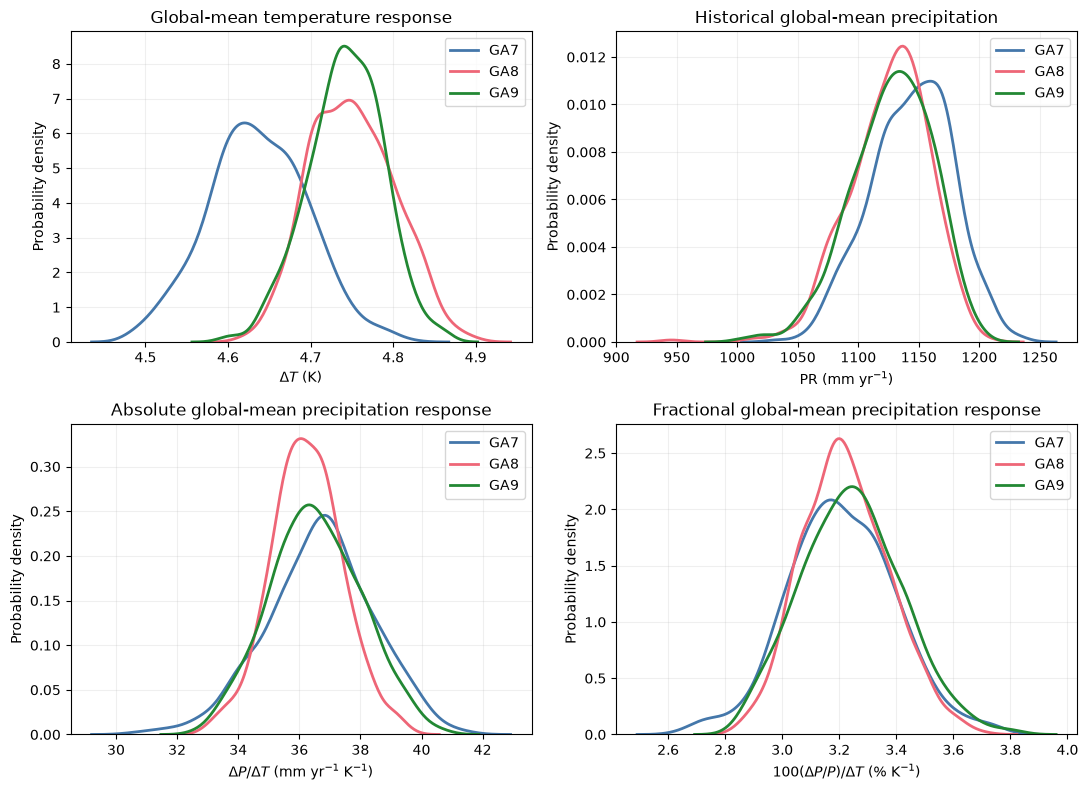

In [4]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

plots = [
    ("deltat", "Global-mean temperature response", r"$\Delta T$ (K)"),
    ("prhis", "Historical global-mean precipitation", r"PR (mm yr$^{-1}$)"),
    (
        "absolute",
        "Absolute global-mean precipitation response",
        r"$\Delta P / \Delta T$ (mm yr$^{-1}$ K$^{-1}$)",
    ),
    (
        "fractional",
        "Fractional global-mean precipitation response",
        r"$100(\Delta P / P) / \Delta T$ (% K$^{-1}$)",
    ),
]

for axis, (field, title, label) in zip(axes.flat, plots):
    for family in familyorder:
        sns.kdeplot(
            familydata[family][field],
            color=familycolors[family],
            label=family,
            fill=False,
            linewidth=2,
            ax=axis,
        )
    axis.set_title(title)
    axis.set_xlabel(label)
    axis.set_ylabel("Probability density")
    axis.grid(alpha=0.2)
    axis.legend()

figure.tight_layout()
figure.savefig(
    "AMS LaTeX Package V6.1/supp_figures/figS1.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Gridded training-target distribution

This diagnostic uses only the 1060 members in the saved training split for the adopted 128-channel model. It shows the distribution of the actual gridded dPdK target in physical units and reports the fraction outside the categorical limits with and without cosine-latitude weighting.


,members,grid_values,unweighted_outside_fraction,unweighted_outside_percent,latitude_weighted_outside_fraction,latitude_weighted_outside_percent
0,1060,26050560,0.000353,0.035293,0.000548,0.054789


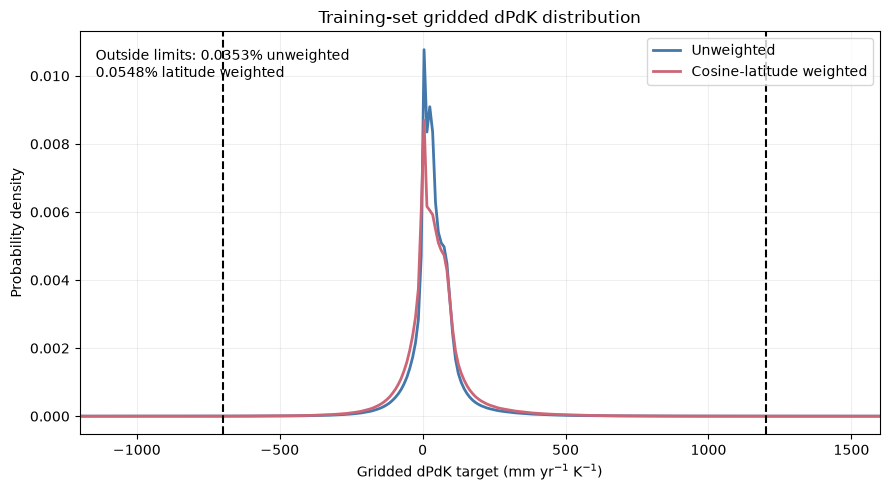

In [5]:
weightspath = Path(
    "/Users/evanwellmeyer/Documents/research/weights/"
    "unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch128_k3_128x_"
    "dPbins64_gn1_dpmin-700_dPmax1200_sigma0.6_dr0.1"
)
targetpath = hadgempath / "GA789_dPdK_rg128.nc"
lowerlimit = -700
upperlimit = 1200

split = np.load(weightspath / "data_splits.npz")
trainindices = split["train"]

with xr.open_dataset(targetpath) as targetfile:
    target = targetfile["dPdK"].isel(realization=trainindices).load()

plotbins = np.linspace(-1200, 1600, 281)
unweightedcounts = np.zeros(plotbins.size - 1)
weightedcounts = np.zeros(plotbins.size - 1)
unweightedtotal = 0
weightedtotal = 0.0
unweightedoutside = 0
weightedoutside = 0.0
latitudeweights = np.cos(np.deg2rad(target.latitude.values))

for latitudeindex, latitudeweight in enumerate(latitudeweights):
    values = target.isel(latitude=latitudeindex).values.ravel()
    values = values[np.isfinite(values)]
    outside = (values < lowerlimit) | (values > upperlimit)

    counts, _ = np.histogram(values, bins=plotbins)
    unweightedcounts += counts
    weightedcounts += counts * latitudeweight
    unweightedtotal += values.size
    weightedtotal += values.size * latitudeweight
    unweightedoutside += outside.sum()
    weightedoutside += outside.sum() * latitudeweight

unweightedfraction = unweightedoutside / unweightedtotal
weightedfraction = weightedoutside / weightedtotal
binwidths = np.diff(plotbins)
bincenters = plotbins[:-1] + binwidths / 2
unweighteddensity = unweightedcounts / unweightedcounts.sum() / binwidths
weighteddensity = weightedcounts / weightedcounts.sum() / binwidths

display(pd.DataFrame({
    "members": [trainindices.size],
    "grid_values": [unweightedtotal],
    "unweighted_outside_fraction": [unweightedfraction],
    "unweighted_outside_percent": [100 * unweightedfraction],
    "latitude_weighted_outside_fraction": [weightedfraction],
    "latitude_weighted_outside_percent": [100 * weightedfraction],
}))

figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(
    bincenters,
    unweighteddensity,
    color="#4477aa",
    linewidth=2,
    label="Unweighted",
)
axis.plot(
    bincenters,
    weighteddensity,
    color="#cc6677",
    linewidth=2,
    label="Cosine-latitude weighted",
)
axis.axvline(lowerlimit, color="black", linestyle="--", linewidth=1.5)
axis.axvline(upperlimit, color="black", linestyle="--", linewidth=1.5)
axis.set_xlim(plotbins[0], plotbins[-1])
axis.set_xlabel(r"Gridded dPdK target (mm yr$^{-1}$ K$^{-1}$)")
axis.set_ylabel("Probability density")
axis.set_title("Training-set gridded dPdK distribution")
axis.grid(alpha=0.2)
axis.legend()
axis.text(
    0.02,
    0.96,
    f"Outside limits: {100 * unweightedfraction:.4f}% unweighted\n"
    f"{100 * weightedfraction:.4f}% latitude weighted",
    transform=axis.transAxes,
    va="top",
)

figure.tight_layout()
figure.savefig(
    "AMS LaTeX Package V6.1/supp_figures/figS_target_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Interpretation

Use the executed family summary to write one restrained sentence about the family-level distributions. Differences among GA7, GA8, and GA9 should be described statistically, without attributing them to individual parameter or physics changes. Use the executed target-distribution table to report the exact training-only fractions outside the categorical limits.
